# 2. LVK compact-binary waveforms with rippleGW

**FQCP 2026 · Bayesian parameter estimation for compact binaries**

> Self-contained and designed for Google Colab. Run top to bottom; **Extension** cells may be skipped live.


## Goal

Use a real IMRPhenomD inspiral–merger–ringdown waveform inside a likelihood we can read. We infer one parameter live to understand likelihood geometry before a production-scale analysis.

This chapter pins `rippleGW==0.2.1`: rippleGW is pre-1.0, so unpinned teaching code may drift.

In [1]:
import os, sys, subprocess, importlib.util
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
if importlib.util.find_spec("ripplegw") is None:
    if IN_COLAB:
        subprocess.check_call([sys.executable,"-m","pip","install","-q","rippleGW==0.2.1"])
    else:
        raise ImportError("Install rippleGW==0.2.1, or run in Colab.")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config, jit
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from ripplegw.conversions import ms_to_Mc_eta
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc

rng=np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["animation.html"]="jshtml"
frequency=jnp.linspace(20.,512.,985); df=float(frequency[1]-frequency[0]); f_ref=20.

def parameters(m1=36.,m2=29.,chi1=.1,chi2=-.1,distance=400.,tc=0.,phase=0.,inclination=.4):
    chirp_mass,eta=ms_to_Mc_eta(jnp.array([m1,m2]))
    return jnp.array([chirp_mass,eta,chi1,chi2,distance,tc,phase,inclination])

@jit
def waveform(theta):
    hp,_=gen_IMRPhenomD_hphc(frequency,theta,f_ref)
    return hp

theta_true=parameters(); h_true=waveform(theta_true)
print("chirp mass",round(float(theta_true[0]),3),"solar masses")
print("symmetric mass ratio",round(float(theta_true[1]),4))

chirp mass 28.096 solar masses
symmetric mass ratio 0.2471


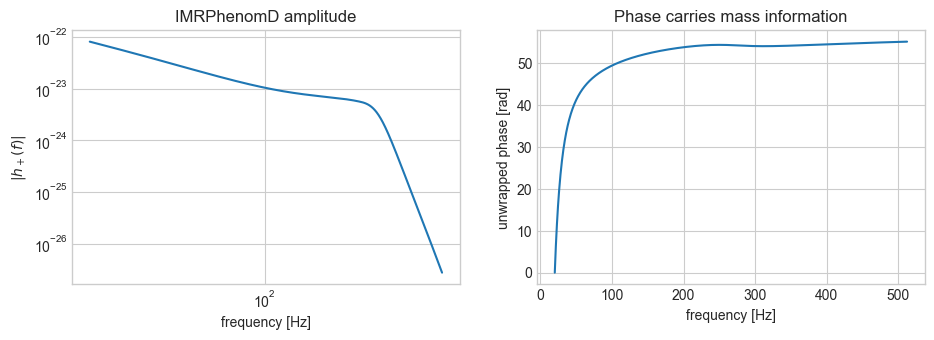

In [3]:
fig,axes=plt.subplots(1,2,figsize=(11,3.3))
axes[0].loglog(np.asarray(frequency),np.abs(np.asarray(h_true)))
axes[0].set(xlabel="frequency [Hz]",ylabel=r"$|h_+(f)|$",title="IMRPhenomD amplitude")
axes[1].plot(np.asarray(frequency),np.unwrap(np.angle(np.asarray(h_true))))
axes[1].set(xlabel="frequency [Hz]",ylabel="unwrapped phase [rad]",title="Phase carries mass information")
plt.show()

## Animation: vary chirp mass

Mass ratio, spins, distance, time, phase, and inclination remain fixed. Chirp mass strongly changes phase evolution.

In [4]:
mass_frames=np.linspace(18,42,30)
fig,ax=plt.subplots(figsize=(7,3.3)); line,=ax.loglog([],[])
ax.set(xlim=(20,512),ylim=(2e-25,2e-22),xlabel="frequency [Hz]",ylabel=r"$|h_+(f)|$")
def update_mass(frame):
    h=np.asarray(waveform(theta_true.at[0].set(mass_frames[frame])))
    line.set_data(np.asarray(frequency),np.abs(h)); ax.set_title(f"chirp mass = {mass_frames[frame]:.1f} solar masses")
    return (line,)
mass_animation=FuncAnimation(fig,update_mass,frames=len(mass_frames),interval=130)
plt.close(fig); display(HTML(mass_animation.to_jshtml()))

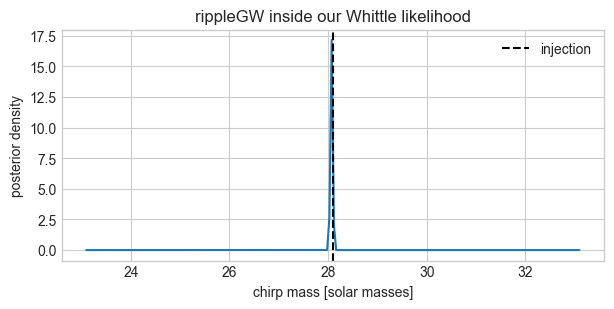

In [5]:
# Simulated one-polarisation data and a toy LVK-like PSD
f=np.asarray(frequency)
psd=(2.2e-23)**2*((35/f)**4+1+(f/260)**2)
noise_scale=np.sqrt(psd/(4*df))
noise=noise_scale*(rng.normal(size=f.size)+1j*rng.normal(size=f.size))
data=np.asarray(h_true)+noise

def log_likelihood(model):
    residual=data-np.asarray(model)
    return -2*df*np.real(np.sum(residual*np.conj(residual)/psd))

mass_grid=np.linspace(float(theta_true[0])-5,float(theta_true[0])+5,220)
log_posterior=np.array([log_likelihood(waveform(theta_true.at[0].set(m))) for m in mass_grid])
posterior=np.exp(log_posterior-log_posterior.max()); posterior/=np.trapezoid(posterior,mass_grid)
fig,ax=plt.subplots(figsize=(7,3)); ax.plot(mass_grid,posterior)
ax.axvline(float(theta_true[0]),color="k",ls="--",label="injection")
ax.set(xlabel="chirp mass [solar masses]",ylabel="posterior density",title="rippleGW inside our Whittle likelihood")
ax.legend(); plt.show()

## Boundary and next steps

rippleGW generated a genuine IMRPhenomD polarisation. The detector analysis is intentionally simplified: one polarisation, analytic PSD, no antenna response/calibration, and one free parameter.

<details><summary>What parameter should be freed next?</summary>

Coalescence time is a good teaching choice because it produces a linear frequency-domain phase shift and a clear correlation. Distance is simpler but mostly changes amplitude.

</details>

- [rippleGW documentation](https://ripplegw.readthedocs.io/)
- [Bilby CBC tutorial](https://bilby-dev.github.io/bilby/compact-binary-coalescence-parameter-estimation.html)
- [GWOSC tutorials](https://gwosc.org/tutorials/)